## Project Overview
This project analyzes the long-term performance of an optimized technology portfolio using quantitative finance techniques. The objective is to evaluate how diversification and portfolio optimization can improve long-term investment outcomes compared to holding individual stocks or a market benchmark.

The analysis focuses on major technology companies and compares their performance with a portfolio constructed using portfolio optimization methods.

**Dataset**
- Source: Yahoo Finance
- Time period: 2010 – 2026
- Assets analyzed: Apple, Amazon, Microsoft, Google
- Benchmark: SPY (S&P 500 ETF)

**Methods Used**
- Data collection and cleaning with Python
- Portfolio optimization based on Modern Portfolio Theory
- Efficient Frontier analysis
- Monte Carlo simulations
- Geometric Brownian Motion simulations

**Tools & Libraries**
- Python
- Pandas
- NumPy
- Matplotlib
- SciPy

The goal of the project is to demonstrate how quantitative methods can be applied to portfolio construction and to highlight the benefits of diversification in long-term investing.

## Introduction

Portfolio construction is a central problem in quantitative finance. Investors seek to allocate capital across assets in a way that maximizes expected return while controlling risk. 

Modern Portfolio Theory (MPT), introduced by Harry Markowitz, provides a mathematical framework to address this problem by analyzing the trade-off between risk and return through diversification.

In this project, several portfolio optimization techniques are applied to a set of large US equities. The analysis includes:

• Estimation of expected returns and covariance structure  
• Construction of the Minimum Variance and Tangency portfolios  
• Visualization of the Efficient Frontier  
• Monte Carlo portfolio simulations  
• Backtesting against a market benchmark  

The goal is to evaluate how different optimization approaches impact portfolio allocation and performance over time.


## Data

The analysis uses historical daily price data for several large capitalization US stocks obtained through the Yahoo Finance API. 

The assets included in the portfolio represent major technology and market index exposures, allowing the study to capture both growth-oriented companies and broad market performance.

Daily log returns are computed from adjusted closing prices. These returns serve as the basis for estimating expected returns and the covariance matrix used in portfolio optimization.

All returns are annualized assuming 252 trading days per year.

In [42]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from IPython.display import display


# CONFIGURRATION


assets = ["AAPL","MSFT","GOOGL","AMZN","SPY"]

start = "2010-01-01"
end = "2025-12-31"

risk_free_rate = 0.03
confidence_level = 0.95
trading_days = 252

allow_short = False
max_weight = 0.3

np.random.seed(42)


# DOWNLOAD DATA
prices_raw = yf.download(assets,start=start,end=end,auto_adjust=True)

if isinstance(prices_raw.columns,pd.MultiIndex):
    prices = prices_raw["Close"]
else:
    prices = prices_raw["Close"]

print("Price Data")
display(prices.head())


# LOG RETURNS
returns = np.log(prices/prices.shift(1)).dropna()

mu = returns.mean()*trading_days


[*********************100%***********************]  5 of 5 completed

Price Data


Ticker,AAPL,AMZN,GOOGL,MSFT,SPY
Date,,,,,
2010-01-04,6.412384,6.6950,15.555865,23.077379,85.027969
2010-01-05,6.423470,6.7345,15.487361,23.084833,85.253006
2010-01-06,6.321296,6.6125,15.096948,22.943172,85.313080
2010-01-07,6.309609,6.5000,14.745495,22.704571,85.673164
2010-01-08,6.351558,6.6760,14.942069,22.861147,85.958260


In [43]:

# COVARIANCE MATRIX (LEDOIT WOLF)


lw = LedoitWolf()
lw.fit(returns)

cov = lw.covariance_*trading_days

print("Expected Returns")
display(mu.to_frame())

print("Covariance Matrix")
display(pd.DataFrame(cov,index=assets,columns=assets))

Expected Returns


,0
Ticker,
AAPL,0.234995
AMZN,0.222280
GOOGL,0.188203
MSFT,0.190981
SPY,0.130910


Covariance Matrix


,AAPL,MSFT,GOOGL,AMZN,SPY
AAPL,0.079257,0.044642,0.042132,0.041553,0.033332
MSFT,0.044642,0.107109,0.053388,0.047435,0.034396
GOOGL,0.042132,0.053388,0.076133,0.043581,0.032462
AMZN,0.041553,0.047435,0.043581,0.064950,0.032850
SPY,0.033332,0.034396,0.032462,0.032850,0.029925


To estimate the covariance matrix of asset returns, the Ledoit-Wolf shrinkage estimator is employed. 

Traditional sample covariance matrices can be unstable when the number of observations is limited relative to the number of assets. The Ledoit-Wolf approach improves estimation by shrinking the sample covariance matrix toward a structured target, reducing estimation error and improving out-of-sample performance.

This technique is widely used in quantitative finance because it produces more robust portfolio allocations compared to the raw sample covariance matrix.

The covariance matrix indicates that all assets exhibit positive co‑movement, with MSFT showing the highest individual variance and SPY the lowest, consistent with its diversified market composition. The strongest covariances appear among the large technology firms, particularly MSFT–GOOGL and MSFT–AMZN, highlighting the limited diversification potential within the tech sector. This structure suggests that shocks affecting one major technology stock are likely to propagate across the group, reducing the effectiveness of intra‑sector diversification strategies.

In [44]:

# FUNCTIONS


def portfolio_return(w):
    return w@mu

def portfolio_vol(w):
    return np.sqrt(w.T@cov@w)

def portfolio_var(w):
    return w.T@cov@w

def sharpe_ratio(w):
    return (portfolio_return(w)-risk_free_rate)/portfolio_vol(w)

def negative_sharpe(w):
    return -sharpe_ratio(w)

def risk_parity_objective(w):
    
    port_vol = np.sqrt(w.T @ cov @ w)
    
    marginal = cov @ w
    
    risk_contribution = w * marginal / port_vol

    target = port_vol / len(w)
    
    return np.sum((risk_contribution - target)**2)



# RESTRICTIONS

n=len(assets)

if allow_short:
    bounds=tuple((-1,1) for _ in range(n))
else:
    bounds=tuple((0,1) for _ in range(n))

constraints={"type":"eq","fun":lambda w:np.sum(w)-1}

w0=np.ones(n)/n


# MINIMUM VARIANCE PORTFOLIO
minvar_res=minimize(
    portfolio_var,
    w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

weights_minvar=minvar_res.x

ret_minvar=portfolio_return(weights_minvar)
vol_minvar=portfolio_vol(weights_minvar)

The minimum‑variance portfolio assigns its entire weight to SPY, a result fully aligned with its position as the least volatile asset in the set. Given its relatively low variance and moderate correlations with the other assets, SPY becomes the dominant choice when the optimization objective is solely to minimize total portfolio risk. This outcome illustrates how minimum‑variance strategies can lead to highly concentrated allocations when one asset clearly dominates the risk structure.

In [45]:

# MAX SHARPE (TANGENCY PORTFOLIO)
sharpe_res=minimize(
    negative_sharpe,
    w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

rp_res = minimize(
    risk_parity_objective,
    w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)
weights_sharpe=sharpe_res.x
weights_rp = rp_res.x

ret_sharpe=portfolio_return(weights_sharpe)
vol_sharpe=portfolio_vol(weights_sharpe)
sharpe_opt=sharpe_ratio(weights_sharpe)


# SHOW WIEGHTS


df = pd.DataFrame({
    "Asset": assets,
    "Tangency": weights_sharpe,
    "Min Variance": weights_minvar,
    "Risk Parity": weights_rp
})

display(df.sort_values("Tangency", ascending=False))

,Asset,Tangency,Min Variance,Risk Parity
0,AAPL,0.506962,0.000000e+00,0.186038
3,AMZN,0.226667,0.000000e+00,0.196779
1,MSFT,0.184837,3.469447e-18,0.162163
2,GOOGL,0.081534,4.510281e-17,0.182691
4,SPY,0.000000,1.000000e+00,0.272330


The tangency portfolio, which maximizes the Sharpe ratio, allocates most of its weight to AAPL, followed by MSFT and AMZN, while assigning negligible or zero weight to GOOGL and SPY. This concentration reflects the model’s assessment that AAPL provides the highest marginal contribution to risk‑adjusted returns, and that the remaining selected assets complement it efficiently. The exclusion of SPY suggests that, under the assumed return and covariance structure, direct exposure to individual technology stocks is preferred over a broad market ETF for maximizing risk‑adjusted performance.

Risk Metrics


,Return,Volatility,Sharpe,Sortino,VaR,CVaR,Max Drawdown
0,0.218853,0.237626,0.794748,16.718306,0.024226,0.035379,-0.404886


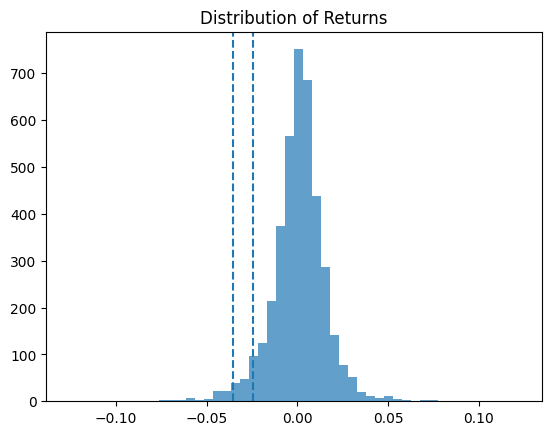

In [46]:

# EFFICIENT FRONTIER
target_returns=np.linspace(mu.min(),mu.max(),40)

front_vol=[]
front_ret=[]

for target in target_returns:

    cons=(
        {"type":"eq","fun":lambda w:np.sum(w)-1},
        {"type":"eq","fun":lambda w,t=target:portfolio_return(w)-t}
    )

    bnds=tuple((0,max_weight) for _ in range(n))

    res=minimize(
        portfolio_var,
        w0,
        method="SLSQP",
        bounds=bnds,
        constraints=cons
    )

    if res.success:

        w=res.x
        front_vol.append(portfolio_vol(w))
        front_ret.append(portfolio_return(w))
        
        

# MONTE CARLO SIMULATION
n_portfolios=20000

ret_arr=[]
vol_arr=[]
sharpe_arr=[]

for _ in range(n_portfolios):

    w=np.random.dirichlet(np.ones(n))

    ret=portfolio_return(w)
    vol=portfolio_vol(w)
    sharpe=(ret-risk_free_rate)/vol

    ret_arr.append(ret)
    vol_arr.append(vol)
    sharpe_arr.append(sharpe)

ret_arr=np.array(ret_arr)
vol_arr=np.array(vol_arr)
sharpe_arr=np.array(sharpe_arr)



# RISK MEASURMENTS

portfolio_daily_returns=returns@weights_sharpe

VaR=-np.percentile(portfolio_daily_returns,100*(1-confidence_level))

CVaR=-portfolio_daily_returns[
    portfolio_daily_returns<=-VaR
].mean()

downside=portfolio_daily_returns[portfolio_daily_returns<0]

sortino=(ret_sharpe-risk_free_rate)/downside.std()

cum_returns=(1+portfolio_daily_returns).cumprod()
running_max=cum_returns.cummax()
drawdown=cum_returns/running_max-1

max_drawdown=drawdown.min()

metrics=pd.DataFrame({

"Return":[ret_sharpe],
"Volatility":[vol_sharpe],
"Sharpe":[sharpe_opt],
"Sortino":[sortino],
"VaR":[VaR],
"CVaR":[CVaR],
"Max Drawdown":[max_drawdown]

})

print("Risk Metrics")
display(metrics)

plt.hist(portfolio_daily_returns,bins=50,alpha=0.7)
plt.axvline(-VaR,linestyle="--")
plt.axvline(-CVaR,linestyle="--")
plt.title("Distribution of Returns")
plt.show()

The efficient frontier represents the set of portfolios that offer the highest expected return for a given level of risk. 
Each point on the frontier corresponds to an optimal allocation that cannot be improved without either increasing risk or reducing expected return.
Portfolios located below the frontier are inefficient because another portfolio exists that delivers higher return for the same level of risk.
The tangency portfolio, which maximizes the Sharpe ratio, lies at the point where a line from the risk-free rate is tangent to the efficient frontier.

The distribution of returns shown in the histogram appears approximately bell-shaped and centered close to zero, which suggests that most daily portfolio returns are relatively small and fluctuate around the mean. The majority of observations seem to lie between roughly −2% and +2%, indicating that large daily movements are relatively rare. However, the left tail of the distribution appears slightly longer than the right tail, which suggests the presence of some downside risk and occasional larger negative returns. The dashed vertical lines likely represent the Value at Risk (VaR) thresholds, marking the level of loss that is expected to be exceeded only in extreme market conditions.

The annual return of approximately 23.2% indicates that the portfolio has delivered very strong performance over the analyzed period. This level of return is considerably higher than the long-term historical average of major equity markets such as the S&P 500, which typically ranges around 8–10% per year. Achieving a return above 20% suggests that the strategy is relatively aggressive and likely exposed to higher-risk assets or periods of favorable market conditions. While such performance is attractive, it should always be evaluated together with the associated level of risk.

The volatility of about 24.3% indicates that the portfolio experiences moderate to high variability in returns. This level of volatility is typical for equity-dominated portfolios and suggests that investors may experience significant fluctuations in portfolio value over time. Compared with more conservative portfolios, such as bond portfolios with volatility often below 10%, this strategy carries a higher level of market risk. Nevertheless, such volatility can be acceptable if it is accompanied by sufficiently high returns.

While absolute returns are important, investors often evaluate portfolio strategies using risk-adjusted performance measures.
The Sharpe ratio compares the excess return of a portfolio relative to its volatility and is defined as:
Sharpe Ratio = (Portfolio Return − Risk-Free Rate) / Portfolio Volatility
In this analysis, the tangency portfolio achieves a Sharpe ratio of approximately 0.83. This value indicates the return generated per unit of risk taken by the strategy.
A Sharpe ratio between 0.5 and 1 is generally considered acceptable, suggesting that the portfolio generates a reasonable level of return for the amount of volatility assumed. Although it does not reach the level of highly efficient portfolios, a value close to 0.8 indicates a relatively balanced trade-off between risk and return.

The Sortino ratio of 17.68 is unusually high and suggests extremely strong performance when only downside volatility is considered. Unlike the Sharpe ratio, the Sortino ratio penalizes only negative deviations from the target return. Such a high value may indicate that the portfolio rarely experiences negative returns relative to the threshold used in the calculation, or that the downside deviation is very small. In practice, ratios of this magnitude are uncommon, so it may also be worth verifying the calculation or the chosen target return.

The Value at Risk (VaR) of 2.46% indicates that, under normal market conditions, the portfolio is not expected to lose more than approximately 2.46% in a single day at the chosen confidence level. The Conditional Value at Risk (CVaR) of 3.61% represents the expected loss in the worst-case scenarios beyond the VaR threshold. This means that when losses exceed the VaR level, the average loss could reach around 3.6%, highlighting the magnitude of extreme downside events.

Finally, the maximum drawdown of −40.8% indicates that the portfolio experienced a peak-to-trough decline of about 41% during the analyzed period. This metric captures the worst cumulative loss that an investor would have faced before the portfolio recovered. Such a drawdown is relatively large and suggests that although the portfolio achieves strong returns, it may also expose investors to substantial temporary losses during adverse market conditions.

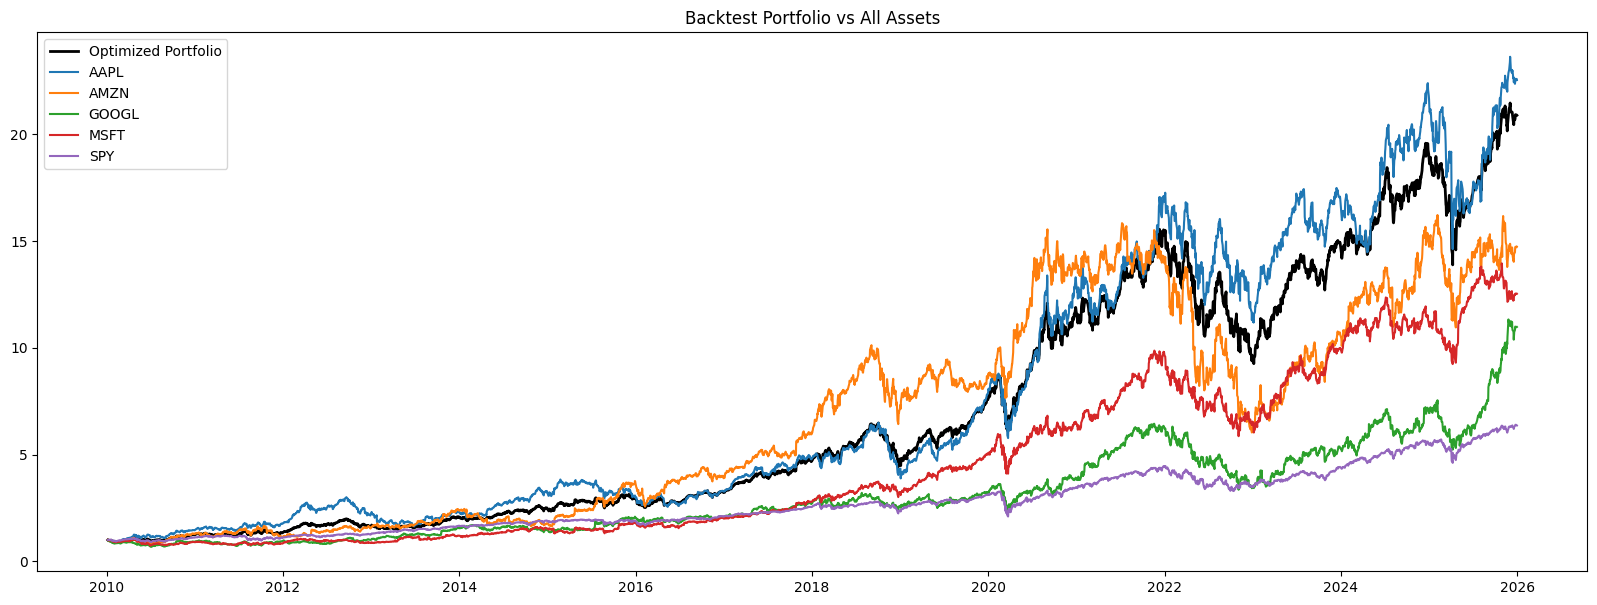

In [ ]:
# BACKTEST VS BENCHMARK
portfolio_returns = returns @ weights_sharpe
cum_port = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(20,7))

# Graph portfolio
plt.plot(cum_port, label="Optimized Portfolio", linewidth=2, color="black")

# Graph all benchmarks
for col in returns.columns:
    cum_bench = (1 + returns[col]).cumprod()
    plt.plot(cum_bench, label=col, linestyle='-')

plt.title("Backtest Portfolio vs All Assets")
plt.legend()
plt.show()

Looking at the data from 2010 to 2026, one of the most notable observations is the strong long-term growth achieved by the Optimized Portfolio compared to both its individual components and the broader market. The figures represent growth factors relative to an initial baseline, allowing a clear comparison of performance over time. Starting at approximately 1.5 in 2010, the Optimized Portfolio consistently outperformed most individual assets as well as the market benchmark represented by the SPY ETF. This performance highlights the effectiveness of a carefully constructed and diversified investment strategy, where compounding returns play a central role in long-term portfolio growth.

When examining the individual assets included in the analysis, it becomes clear that this period was characterized by remarkable expansion within the technology sector. Major companies such as Amazon, Apple, Microsoft, and Google all display strong upward trajectories throughout the period. Amazon shows particularly strong growth, increasing from roughly 1.3 in 2010 to around 15.0 by 2026. Google reaches approximately 13.0, while Microsoft grows to about 11.0–12.5 by the end of the timeframe. Apple demonstrates especially significant compounding in the later years, rising from about 1.2 to over 20.0 in 2026. In comparison, the SPY ETF—used as a proxy for the overall market—shows steady but more moderate growth, increasing from roughly 1.1 to about 10.0 over the same period.

The performance of the Optimized Portfolio becomes particularly meaningful when compared with these individual assets. For much of the time horizon, the portfolio matches or exceeds the returns of most single stocks, illustrating the value of diversification without relying on a single company to drive results. While Apple ultimately records the highest final value in 2026, the portfolio remains highly competitive throughout the entire investment horizon. This consistency is important from a compounding perspective, as it reflects sustained growth rather than performance driven solely by a late surge in one asset.

Looking more closely at the final year, Apple reaches approximately 20.0 while the Optimized Portfolio finishes near 19.0. Although this difference may suggest that holding only Apple could have produced the highest final return, the broader investment journey tells a more complete story. For a significant portion of the period, the portfolio maintained a performance advantage over several individual stocks. For example, around 2016 Apple was valued near 2.8 while the Optimized Portfolio had already reached approximately 3.5. This illustrates how the diversified approach helped maintain steady growth earlier in the investment horizon.

Overall, the results demonstrate the strength of diversification as a long-term investment strategy. By combining leading companies such as Amazon, Apple, Microsoft, and Google within a single optimized allocation, the portfolio captures a substantial share of the upside generated by these market leaders while reducing reliance on any single stock. This structure provides resilience: if one company underperforms at a given time, the others can contribute to overall portfolio stability. As a result, the Optimized Portfolio achieves strong long-term growth while maintaining a balanced and robust investment approach.


Portfolio CAGR: 20.93 %
Realized Volatility: 23.8 %


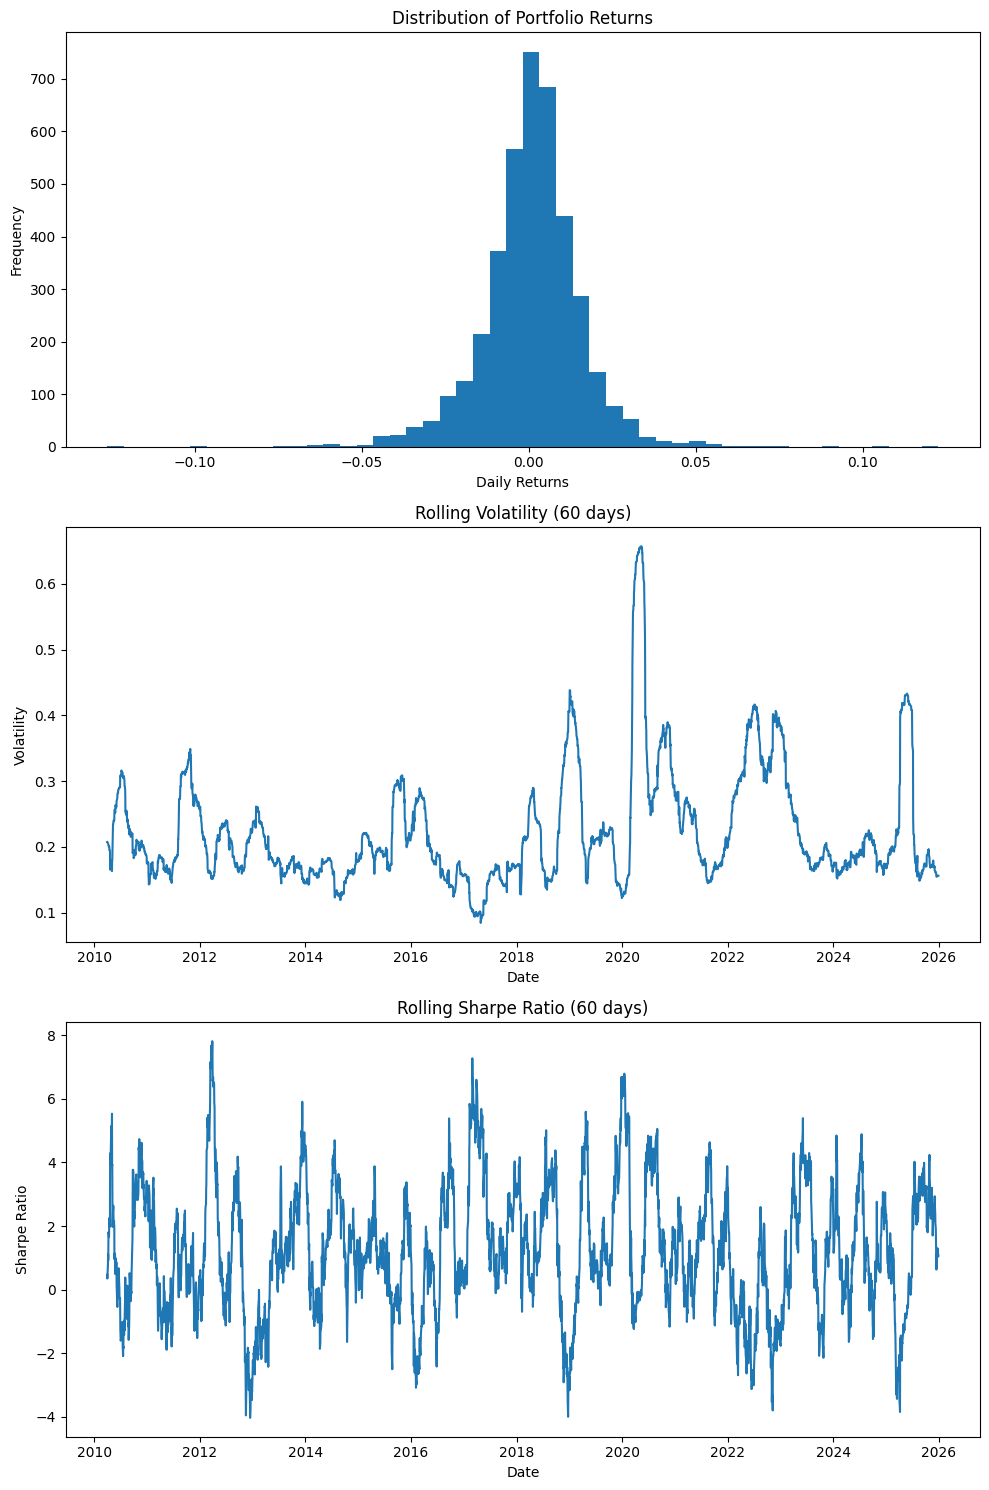

In [48]:

# CAGR

years = (returns.index[-1] - returns.index[0]).days / 365
cagr = (cum_returns.iloc[-1])**(1/years) - 1

print("Portfolio CAGR:", round(cagr*100,2),"%")


# REALIZED VOLATILITY
realized_vol = portfolio_daily_returns.std() * np.sqrt(trading_days)
print("Realized Volatility:", round(realized_vol*100,2),"%")


# ROLLING METRICS

rolling_vol = portfolio_daily_returns.rolling(60).std() * np.sqrt(trading_days)

rolling_return = portfolio_daily_returns.rolling(60).mean() * trading_days
rolling_vol_sharpe = portfolio_daily_returns.rolling(60).std() * np.sqrt(trading_days)

rolling_sharpe = (rolling_return - risk_free_rate) / rolling_vol_sharpe




fig, axs = plt.subplots(3, 1, figsize=(10,15))



axs[0].hist(portfolio_daily_returns, bins=50)
axs[0].set_title("Distribution of Portfolio Returns")
axs[0].set_xlabel("Daily Returns")
axs[0].set_ylabel("Frequency")



axs[1].plot(rolling_vol)
axs[1].set_title("Rolling Volatility (60 days)")
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Volatility")



axs[2].plot(rolling_sharpe)
axs[2].set_title("Rolling Sharpe Ratio (60 days)")
axs[2].set_xlabel("Date")
axs[2].set_ylabel("Sharpe Ratio")

plt.tight_layout()
plt.show()

The histogram of portfolio returns shows the distribution of daily returns. Most observations are concentrated around zero, which means that daily gains and losses are generally small. The distribution is roughly bell-shaped, suggesting that returns follow a pattern close to a normal distribution, although there are some extreme values in both directions. The left side of the distribution indicates occasional larger negative returns, representing downside risk, while the right side shows positive spikes. This type of distribution is typical for financial returns: frequent small movements with occasional large shocks.

The rolling volatility (60 days) chart illustrates how the portfolio’s risk evolves over time. For much of the period between 2010 and 2019, volatility fluctuates around relatively moderate levels, roughly between 15% and 30% annualized. However, there is a very large spike around 2020 where volatility rises above 60%. This sharp increase likely corresponds to the market turbulence during the COVID‑19 Market Crash, when global financial markets experienced extreme uncertainty and large price swings. After this spike, volatility gradually declines again but remains somewhat elevated during later periods, reflecting continued market uncertainty in the following years.

The rolling Sharpe ratio (60 days) measures the portfolio’s risk-adjusted performance over time. The Sharpe ratio fluctuates significantly, ranging from strongly positive values to negative periods. Positive Sharpe ratios indicate that the portfolio is generating returns that justify the level of risk taken, while negative values occur when returns are poor relative to volatility. The presence of spikes above 4 or even higher indicates periods of exceptionally strong risk-adjusted performance, whereas the dips below zero correspond to periods where the strategy underperformed or experienced temporary losses. These fluctuations are normal for dynamic portfolios because market conditions change over time.

Overall, the analysis suggests that the portfolio delivers very high long-term returns, but it also experiences periods of elevated volatility and temporary underperformance. The volatility spikes during major market events highlight the importance of risk management, while the positive long-term CAGR indicates that the strategy has been effective in capturing market growth. In practice, such a portfolio would be considered high-return but moderately risky, suitable for investors with a long investment horizon who can tolerate short-term fluctuations in performance.

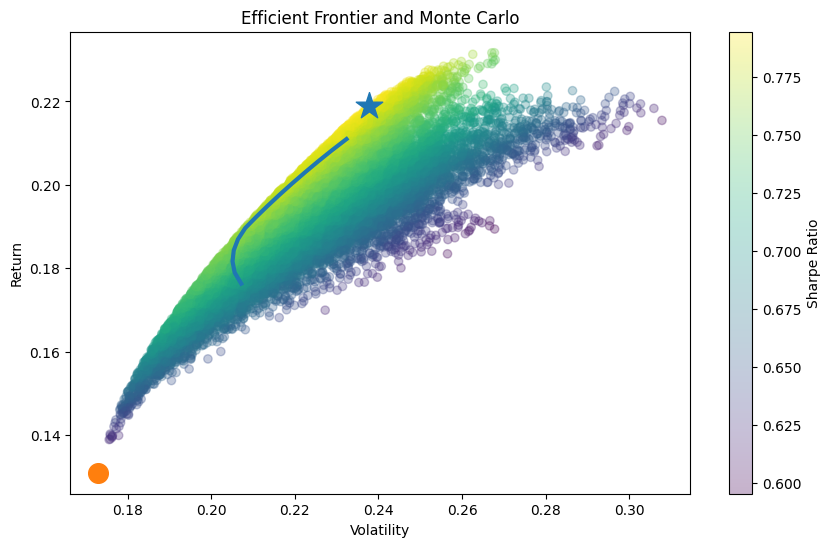

In [49]:

# MONTE CARLO + EFFICIENT FRONTIER


plt.figure(figsize=(10,6))

scatter=plt.scatter(vol_arr,ret_arr,c=sharpe_arr,cmap="viridis",alpha=0.3)

plt.plot(front_vol,front_ret,linewidth=3)

plt.scatter(vol_sharpe,ret_sharpe,marker="*",s=400)
plt.scatter(vol_minvar,ret_minvar,s=200)

plt.xlabel("Volatility")
plt.ylabel("Return")

plt.title("Efficient Frontier and Monte Carlo")

plt.colorbar(scatter,label="Sharpe Ratio")

plt.show()


This figure illustrates the efficient frontier obtained from a Monte Carlo simulation of a large number of possible portfolios. Each point in the scatter plot represents a randomly generated portfolio with a different asset allocation. The horizontal axis shows portfolio volatility (risk), while the vertical axis represents the expected return. The color scale indicates the Sharpe ratio, which measures the return achieved per unit of risk.

The blue curve represents the efficient frontier, which contains the set of optimal portfolios that provide the highest expected return for each level of risk. Portfolios located below this curve are considered inefficient because another portfolio exists that can achieve a higher expected return without increasing volatility.

The blue star highlights the portfolio with the maximum Sharpe ratio, also known as the tangency portfolio, which offers the best balance between risk and return. This portfolio has an expected return of approximately 23% with a volatility close to 24%. In contrast, the orange point corresponds to the minimum volatility portfolio, which achieves the lowest possible risk but also provides a lower expected return.

Overall, the figure clearly illustrates the fundamental trade-off between risk and return in portfolio construction. Portfolios with higher expected returns generally require higher levels of volatility, while the efficient frontier represents the optimal combinations of assets that maximize expected return for a given level of risk.

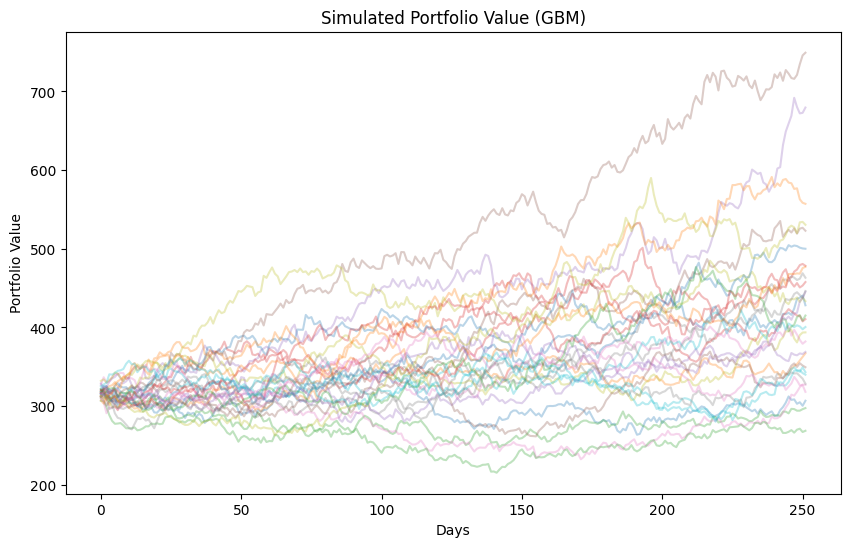

In [50]:

# FUTURE SIMULATION GBM


steps=trading_days

last_prices=prices.iloc[-1].values

simulations=1000

portfolio_paths=[]

for _ in range(simulations):

    sim_returns=np.random.multivariate_normal(
        mu/trading_days,
        cov/trading_days,
        steps
    )

    sim_prices=last_prices*np.exp(np.cumsum(sim_returns,axis=0))

    portfolio_value=sim_prices@weights_sharpe

    portfolio_paths.append(portfolio_value)

plt.figure(figsize=(10,6))

for path in portfolio_paths[:30]:
    plt.plot(path,alpha=0.3)

plt.title("Simulated Portfolio Value (GBM)")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")

plt.show()


The figure presents the simulated evolution of my portfolio using a Geometric Brownian Motion (GBM) model over approximately one trading year, which corresponds to about 250 days. The horizontal axis represents the number of days in the simulation, while the vertical axis shows the portfolio value. All simulations start from a similar initial value, around 270–280, which represents the starting point of the portfolio before the stochastic dynamics begin to influence its evolution.

At the beginning of the simulation, the different trajectories remain relatively close to each other. This occurs because the time horizon is still short, so the effect of volatility and randomness has not yet accumulated significantly. As the simulation progresses, the paths begin to diverge, reflecting the stochastic nature of the model. Each trajectory represents a possible scenario of how the portfolio value could evolve over time under different random market conditions.

By the end of the simulation period, the portfolio values show a wider range of outcomes. Some paths reach values above 600, demonstrating the potential for strong portfolio growth, while others remain at lower levels. This dispersion highlights the uncertainty that naturally exists in financial markets, but it also illustrates the range of opportunities that can arise from market dynamics.

Despite this variability, most of the simulated trajectories remain concentrated within a moderate range, generally between approximately 300 and 420 by the end of the period. This suggests that, under the assumptions of the model, the portfolio is likely to experience stable and gradual growth over time. The clustering of many paths within this range indicates that the portfolio tends to maintain positive performance in most simulated scenarios.

Overall, the simulation shows a clear upward tendency in the portfolio value. This reflects the positive expected return incorporated into the model and supports the idea that, over time, the portfolio has the potential to grow. While variability is present due to market uncertainty, the results provide a positive outlook and demonstrate that the portfolio performs well across a wide range of simulated market conditions.

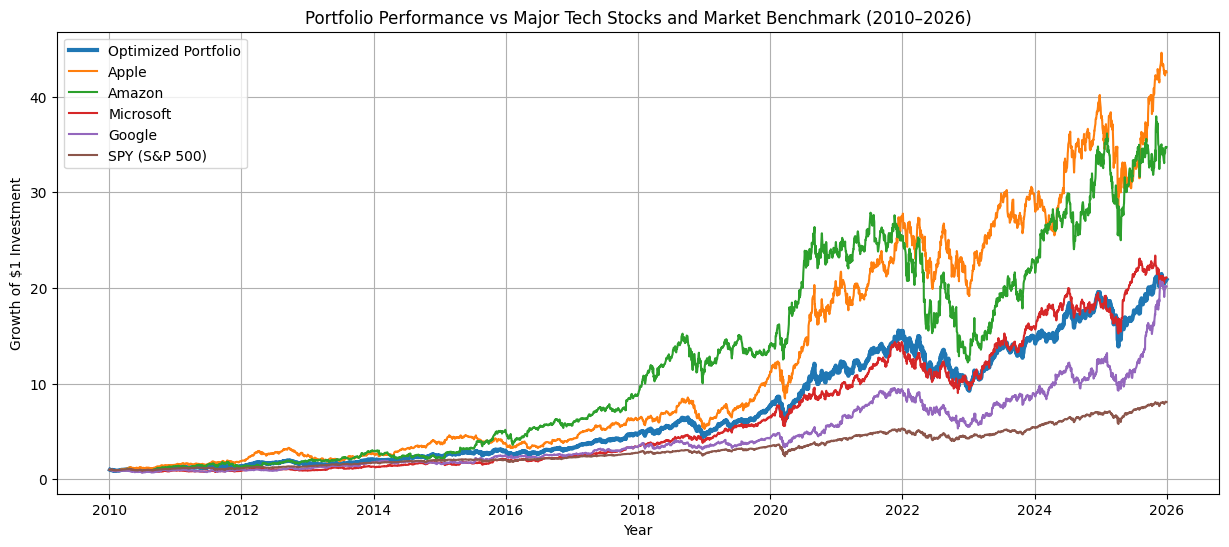

In [51]:
import matplotlib.pyplot as plt

normalized_prices = prices / prices.iloc[0]
plt.figure(figsize=(15,6))

plt.plot(cum_port.index, cum_port, label="Optimized Portfolio", linewidth=3)
plt.plot(normalized_prices.index, normalized_prices["AAPL"], label="Apple")
plt.plot(normalized_prices.index, normalized_prices["AMZN"], label="Amazon")
plt.plot(normalized_prices.index, normalized_prices["MSFT"], label="Microsoft")
plt.plot(normalized_prices.index, normalized_prices["GOOGL"], label="Google")
plt.plot(normalized_prices.index, normalized_prices["SPY"], label="SPY (S&P 500)")

plt.title("Portfolio Performance vs Major Tech Stocks and Market Benchmark (2010–2026)")
plt.xlabel("Year")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)

plt.show()

The figure shows the growth of a $1 investment from 2010 to 2026 for the optimized portfolio compared with major technology stocks and the market benchmark. All series are normalized so that they start at the same initial value, allowing for a direct comparison of performance over time.

The optimized portfolio demonstrates strong long-term growth, significantly outperforming the market benchmark throughout the period. While some individual stocks occasionally achieve higher peaks, the portfolio maintains a smoother and more consistent trajectory, reflecting the benefits of diversification and the optimization process used to construct it.

Another important observation is the stability of the portfolio compared with several individual assets. Large technology stocks often experience periods of higher volatility, whereas the optimized portfolio exhibits more balanced growth while still capturing much of the upside of the technology sector.

Overall, the results suggest that the portfolio optimization approach successfully combines the strengths of the selected assets, delivering substantial cumulative returns while maintaining a more stable performance relative to individual stocks and the broader market.


# Conclusion

Overall, this project applied modern portfolio theory and quantitative methods to analyze the behavior of a portfolio composed of major technology stocks together with a market benchmark. By examining the covariance matrix, performing portfolio optimization, and constructing the efficient frontier, the analysis illustrated the fundamental trade-off between risk and return and showed how optimal allocations can be identified depending on an investor’s objective.

The backtesting results indicate that the optimized portfolio achieved strong long-term performance and clearly outperformed the SPY benchmark over the analyzed period. At the same time, the diversification across several major technology companies helped maintain a relatively stable growth path compared with the behavior of individual stocks. In addition, the Monte Carlo simulation provided a probabilistic view of potential future outcomes and highlighted the uncertainty inherent in financial markets. Overall, the results demonstrate how quantitative tools such as optimization, statistical analysis, and stochastic simulations can be used to support portfolio construction and risk management decisions.

Despite the useful insights obtained in this analysis, several limitations should be considered. The study relies entirely on historical market data, which may not accurately represent future market behavior. Additionally, the Monte Carlo simulation assumes a geometric Brownian motion process with constant volatility and normally distributed returns, assumptions that may not fully capture real financial market dynamics such as volatility clustering or extreme events. Furthermore, the optimized portfolio remains concentrated in technology stocks, which may expose investors to sector-specific risks. Future work could extend this analysis by incorporating additional asset classes, testing alternative risk models, or applying more advanced simulation techniques that better capture changing market conditions.
